# SCL 2.0 vs CVAE/RVAE — Comparación de Complejidad Armónica

**Objetivo:** Comparar SCL 2.0 (v1 weighted, v2 equal) contra CVAE/RVAE del paper,
generando 5 niveles de complejidad a partir de una progresión simple.

**Progresión inicial:** `Cmin | Gmaj | Cmin | Fmin | Cmin`

---

### Diferencia clave entre v1 y v2

Ambas usan el mismo modelo (checkpoint v13, z_only_decoder). Lo que cambia es
**la función de pérdida del gradient ascent** que guía el enrichment:

| Versión | Target de la loss | Efecto en el gradiente |
|---------|-------------------|------------------------|
| **v1 (weighted)** | `MSE(PCS_w, target)` donde `PCS_w = Σ(w_d·c_d)/Σw_d` | Empuja más 7C (peso 0.443) y VNSPC (0.378) |
| **v2 (equal)** | `MSE(PCS_eq, target)` donde `PCS_eq = mean(c_0..c_3)` | Empuja las 4 dimensiones por igual |

Para alcanzar PCS=0.5, **v1 prioriza agregar séptimas**, mientras
**v2 distribuye el esfuerzo** entre disonancia, variabilidad y diversidad interválica.

---

### Pipeline de inferencia
```
Input → Encoder → z_orig (32-dim)
  ↓
Gradient Ascent (Adam, lr=0.5, 90 steps):
  loss = MSE(pcs_fn(c_predictor(z)), target_pcs) + 0.005·MSE(z, z_orig)
  ↓
z_enriched → Decoder → progresión
```

In [1]:
import sys, warnings, json, re
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Project root
for _root in [Path.cwd(), Path.cwd().parent]:
    if (_root / "cvae" / "models" / "rvae.py").exists():
        PROJECT_ROOT = _root; break
else:
    PROJECT_ROOT = Path("/home/pepebeats/SCL_2.0")
sys.path.insert(0, str(PROJECT_ROOT))

from cvae.models.rvae import RVAE
from chords.chord_encoder import (
    decode_chord, progression_to_encoding, parse_chord,
    SEVENTH_SLOT, EXT_SLOT, BASS_SLOT,
)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
KEY_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
C_NAMES  = ['7C','VNSPC','DTMCVI','VDR']
C_DIMS   = 4

# ── Pesos del estudio perceptual ──
with open(PROJECT_ROOT / 'PCS' / 'pcs_weights.json') as f:
    _pw = json.load(f)
W_V1 = np.array([
    _pw['Seventh_Chords']['weight'],
    _pw['Variability_of_Number_of_Simultaneous_Pitch_Classes']['weight'],
    _pw['Distance_Between_Two_Most_Common_Vertical_Intervals']['weight'],
    _pw['Vertical_Dissonance_Ratio']['weight'],
])
W_V1_T = torch.tensor(W_V1, dtype=torch.float32, device=DEVICE)

# ── Funciones PCS ──
def pcs_weighted_torch(c_pred):
    """SCL v1: PCS ponderado. c_pred: tensor (B,4) o (4,) → escalar."""
    return (c_pred * W_V1_T).sum(dim=-1) / W_V1_T.sum()

def pcs_equal_torch(c_pred):
    """SCL v2: PCS promediado."""
    return c_pred.mean(dim=-1)

def pcs_weighted(c):
    """Versión numpy de PCS v1."""
    return float(np.dot(W_V1, np.asarray(c)) / W_V1.sum())

def pcs_equal(c):
    """Versión numpy de PCS v2."""
    return float(np.asarray(c).mean())

# ── Conversor de notación SCL → paper ──
def scl_to_paper(chord_str):
    """Cm→Cmin, G→Gmaj, G7→G7, Cmaj7→Cmaj7."""
    m = re.match(r'([A-G](?:#|b)?)(.*)', chord_str)
    if not m:
        return chord_str
    root, rest = m.group(1), m.group(2)
    # Orden importa: maj/min antes que m
    if rest.startswith('min'):
        pass
    elif rest.startswith('maj'):
        pass
    elif rest.startswith('mmaj7'):
        rest = 'minmaj7' + rest[5:]
    elif rest.startswith('m7'):
        rest = 'min7' + rest[2:]
    elif rest.startswith('m9'):
        rest = 'min9' + rest[2:]
    elif rest.startswith('m11'):
        rest = 'min11' + rest[3:]
    elif rest.startswith('m13'):
        rest = 'min13' + rest[3:]
    elif rest.startswith('m'):
        rest = 'min' + rest[1:]
    # Solo agregar 'maj' si no hay calidad ni séptima
    elif rest == '':
        rest = 'maj'
    elif not (rest[0].isdigit() or rest[:3] in ('dim','aug','sus','no3')):
        rest = 'maj' + rest
    return root + rest

print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')
print(f'PCS v1: Σ={W_V1.sum():.3f}  {dict(zip(C_NAMES, W_V1.round(4)))}')
print(f'PCS v2: Σ=1.000  {dict(zip(C_NAMES, [0.25]*4))}')

Device: cuda  |  PyTorch: 2.6.0+cu124
PCS v1: Σ=1.360  {'7C': np.float64(0.443), 'VNSPC': np.float64(0.3777), 'DTMCVI': np.float64(0.3383), 'VDR': np.float64(0.2007)}
PCS v2: Σ=1.000  {'7C': 0.25, 'VNSPC': 0.25, 'DTMCVI': 0.25, 'VDR': 0.25}


In [2]:
# ── Cargar modelo ──
CHECKPOINT = PROJECT_ROOT / 'checkpoints' / 'rvae_key_v13' / 'best.pt'
model = RVAE(latent_dim=32, condition_dim=16, z_only_decoder=True).to(DEVICE)
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

vl = ckpt.get('val_loss','?')
print(f'Checkpoint v13 | Época {ckpt.get("epoch","?")} | Val loss: {vl:.4f}' if isinstance(vl,float) else f'Checkpoint v13')
print(f'Latent=32 | Cond=16 (4PCS+12key) | Params={sum(p.numel() for p in model.parameters()):,}')

Checkpoint v13 | Época 30 | Val loss: 4.2376
Latent=32 | Cond=16 (4PCS+12key) | Params=3,145,552


In [3]:
# ── Funciones auxiliares ──

def detect_key(seq):
    roots = seq[:, :12].argmax(dim=-1)
    k = roots.bincount(minlength=12).argmax().item()
    oh = torch.zeros(12); oh[k] = 1.0; return oh

def make_cond(key_oh):
    return torch.cat([torch.zeros(C_DIMS), key_oh]).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def encode(model, seq):
    sb = seq.unsqueeze(0).to(DEVICE)
    mu, lv = model.encoder(sb, torch.tensor([seq.size(0)], device=DEVICE))
    z = model.reparameterize(mu, lv)
    cond = make_cond(detect_key(seq))
    gen = model.generate(z, cond, max_len=seq.size(0), device=DEVICE)
    return z, gen[0], cond

@torch.no_grad()
def decode_to_chords(model, z, n, cond):
    gen = model.generate(z, cond, max_len=n, device=DEVICE)
    return [decode_chord(gen[0,t].cpu().numpy()) for t in range(n)], gen[0]

def count_7th_ext(seq):
    n7 = n_ext = 0
    for t in range(seq.size(0)):
        if int(seq[t, SEVENTH_SLOT:EXT_SLOT].argmax()) != 0: n7 += 1
        n_ext += int(seq[t, EXT_SLOT:BASS_SLOT].sum().item())
    return n7, n_ext


def enrich_pcs(model, z_orig, cond, n, target_pcs, pcs_fn_torch,
               lr=0.5, steps=90, reg=0.005):
    """
    Gradient ascent sobre z para alcanzar un PCS escalar target.
    
    Args:
        target_pcs: float ∈ [0,1] — PCS objetivo
        pcs_fn_torch: pcs_weighted_torch (v1) o pcs_equal_torch (v2)
    Returns:
        (chords, seq, c_init, c_final, pcs_init, pcs_final)
    """
    z_opt = z_orig.clone().detach().requires_grad_(True)

    with torch.no_grad():
        c_init = model.c_predictor(z_opt)[0].clone()
        pcs_init = pcs_fn_torch(c_init).item()

    if abs(target_pcs - pcs_init) < 0.002:
        chords, seq = decode_to_chords(model, z_opt, n, cond)
        return chords, seq, c_init.tolist(), c_init.tolist(), pcs_init, pcs_init

    opt = torch.optim.Adam([z_opt], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        c_pred = model.c_predictor(z_opt)[0]
        pcs_pred = pcs_fn_torch(c_pred)
        loss = F.mse_loss(pcs_pred, torch.tensor(target_pcs, device=DEVICE))
        loss += reg * F.mse_loss(z_opt, z_orig.detach())
        loss.backward()
        torch.nn.utils.clip_grad_norm_([z_opt], max_norm=1.0)
        opt.step()

    with torch.no_grad():
        c_final = model.c_predictor(z_opt)[0].clone()
        pcs_final = pcs_fn_torch(c_final).item()
        chords, seq = decode_to_chords(model, z_opt.detach(), n, cond)

    return chords, seq, c_init.tolist(), c_final.tolist(), pcs_init, pcs_final


def enrich_single_dim(model, z_orig, cond, n, dim_idx, target_val,
                      lr=0.5, steps=90, reg=0.005):
    """Enriquece una sola dimensión PCS."""
    z_opt = z_orig.clone().detach().requires_grad_(True)
    with torch.no_grad():
        c_init = model.c_predictor(z_opt)[0].clone()
    opt = torch.optim.Adam([z_opt], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        c_pred = model.c_predictor(z_opt)[0]
        loss = F.mse_loss(c_pred[dim_idx], torch.tensor(target_val, device=DEVICE))
        loss += reg * F.mse_loss(z_opt, z_orig.detach())
        loss.backward()
        torch.nn.utils.clip_grad_norm_([z_opt], max_norm=1.0)
        opt.step()
    with torch.no_grad():
        c_final = model.c_predictor(z_opt)[0].clone()
        chords, seq = decode_to_chords(model, z_opt.detach(), n, cond)
    return chords, seq, c_init.tolist(), c_final.tolist()


def enrich_pcs_with_trace(model, z_orig, cond, n, target_pcs, pcs_fn_torch,
                          lr=0.5, steps=90, reg=0.005):
    """Como enrich_pcs pero retorna la trayectoria PCS de cada step."""
    z_opt = z_orig.clone().detach().requires_grad_(True)
    with torch.no_grad():
        c_init = model.c_predictor(z_opt)[0].clone()
        pcs_init = pcs_fn_torch(c_init).item()
    pcs_trace = [pcs_init]
    opt = torch.optim.Adam([z_opt], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        c_pred = model.c_predictor(z_opt)[0]
        pcs_pred = pcs_fn_torch(c_pred)
        loss = F.mse_loss(pcs_pred, torch.tensor(target_pcs, device=DEVICE))
        loss += reg * F.mse_loss(z_opt, z_orig.detach())
        loss.backward()
        torch.nn.utils.clip_grad_norm_([z_opt], max_norm=1.0)
        opt.step()
        with torch.no_grad():
            pcs_trace.append(pcs_fn_torch(model.c_predictor(z_opt)[0]).item())
    with torch.no_grad():
        c_final = model.c_predictor(z_opt)[0].clone()
        chords, seq = decode_to_chords(model, z_opt.detach(), n, cond)
    return chords, c_final.tolist(), pcs_trace

print('✓ Funciones listas')

✓ Funciones listas


In [4]:
# ── Procesar progresión inicial ──
INPUT_CHORDS = ['Cmin', 'Gmaj', 'Cmin', 'Fmin', 'Cmin']
N = len(INPUT_CHORDS)

print('Input:')
for c in INPUT_CHORDS:
    p = parse_chord(c)
    print(f'  {c:8s} → {KEY_NAMES[p["root"]]:2s} {p["quality"]:5s} {p["seventh"]}')

seq_np = progression_to_encoding(INPUT_CHORDS)
seq = torch.from_numpy(seq_np).float()
print(f'Encoded: {seq.shape}')

Input:
  Cmin     → C  min   none
  Gmaj     → G  maj   none
  Cmin     → C  min   none
  Fmin     → F  min   none
  Cmin     → C  min   none
Encoded: torch.Size([5, 48])


In [5]:
# ── Encoder → z_orig ──
z_orig, gen_recon, cond = encode(model, seq)
recon_chords = [decode_chord(gen_recon[t].cpu().numpy()) for t in range(N)]
n7_r, ext_r = count_7th_ext(gen_recon)

with torch.no_grad():
    c_orig = model.c_predictor(z_orig)[0].tolist()

print(f'z: {z_orig.shape}  ||z||={z_orig.norm().item():.2f}')
print(f'Key: {KEY_NAMES[cond[0,4:].argmax().item()]}')
print(f'Recon (SCL):  {" | ".join(recon_chords)}')
print(f'Recon (paper): {" | ".join(scl_to_paper(c) for c in recon_chords)}')
print(f'7ths={n7_r}/{N}')
print(f'C inicial: 7C={c_orig[0]:.3f} VNSPC={c_orig[1]:.3f} DTMCVI={c_orig[2]:.3f} VDR={c_orig[3]:.3f}')
print(f'PCS_w={pcs_weighted(c_orig):.4f}  PCS_eq={pcs_equal(c_orig):.4f}')

z: torch.Size([1, 32])  ||z||=8.83
Key: C
Recon (SCL):  Am | C | C | Fm | G#
Recon (paper): Amin | Cmaj | Cmaj | Fmin | G#maj
7ths=0/5
C inicial: 7C=0.002 VNSPC=-0.002 DTMCVI=0.007 VDR=0.005
PCS_w=0.0027  PCS_eq=0.0031


## SCL v1 — Enrichment con PCS Ponderado

**Targets:** 0.00, 0.25, 0.50, 0.75, 1.00

**Loss:** `MSE(PCS_w(c_pred), target)` — gradiente empuja más 7C (peso 0.443).

In [6]:
TARGETS = [0.00, 0.25, 0.50, 0.75, 1.00]

print('═══ SCL v1 — PCS ponderado ═══')
print(f'{"Lv":<3s} {"Tgt":<6s} {"PCS_w":<7s} {"7C":<7s} {"VNSPC":<7s} {"DTMCVI":<7s} {"VDR":<7s} {"7th":<5s} {"Progresión"}')
print('─' * 100)

results_v1 = []
for lv, tgt in enumerate(TARGETS, 1):
    chords, seq_g, c_i, c_f, pcs_i, pcs_f = enrich_pcs(
        model, z_orig, cond, N, tgt, pcs_weighted_torch)
    n7, ext = count_7th_ext(seq_g)
    results_v1.append((lv, tgt, chords, c_i, c_f, pcs_i, pcs_f, n7, ext))
    paper = ' | '.join(scl_to_paper(c) for c in chords)
    print(f'{lv:<3d} {tgt:<6.2f} {pcs_f:<7.4f} {c_f[0]:<7.3f} {c_f[1]:<7.3f} {c_f[2]:<7.3f} {c_f[3]:<7.3f} {n7}/{N:<4d} {paper}')

═══ SCL v1 — PCS ponderado ═══
Lv  Tgt    PCS_w   7C      VNSPC   DTMCVI  VDR     7th   Progresión
────────────────────────────────────────────────────────────────────────────────────────────────────


1   0.00   0.0022  0.002   -0.001  0.005   0.004   0/5    Emin | Cmaj | Cmaj | Amaj | Cmaj
2   0.25   0.2399  0.007   0.375   0.444   0.155   0/5    G#min | Cmin | Ano3d | Cmaj | Dmin


3   0.50   0.4796  0.134   0.679   0.766   0.385   1/5    Cno3d | Cmaj | Cno3d | Cno3dmaj7 | Cno3d
4   0.75   0.7101  0.349   1.009   0.873   0.669   2/5    Gminmaj7 | Cno3d | Cno3d | Cmaj | Cmin7


5   1.00   0.9444  0.650   1.245   0.985   0.961   2/5    Gmaj | Cmin | Cno3dmaj7 | Dno3d | Dmin7


## SCL v2 — Enrichment con PCS Promediado

**Targets:** 0.00, 0.25, 0.50, 0.75, 1.00

**Loss:** `MSE(PCS_eq(c_pred), target)` — gradiente empuja las 4 dimensiones por igual.

In [7]:
print('═══ SCL v2 — PCS promediado ═══')
print(f'{"Lv":<3s} {"Tgt":<6s} {"PCS_eq":<7s} {"7C":<7s} {"VNSPC":<7s} {"DTMCVI":<7s} {"VDR":<7s} {"7th":<5s} {"Progresión"}')
print('─' * 100)

results_v2 = []
for lv, tgt in enumerate(TARGETS, 1):
    chords, seq_g, c_i, c_f, pcs_i, pcs_f = enrich_pcs(
        model, z_orig, cond, N, tgt, pcs_equal_torch)
    n7, ext = count_7th_ext(seq_g)
    results_v2.append((lv, tgt, chords, c_i, c_f, pcs_i, pcs_f, n7, ext))
    paper = ' | '.join(scl_to_paper(c) for c in chords)
    print(f'{lv:<3d} {tgt:<6.2f} {pcs_f:<7.4f} {c_f[0]:<7.3f} {c_f[1]:<7.3f} {c_f[2]:<7.3f} {c_f[3]:<7.3f} {n7}/{N:<4d} {paper}')

═══ SCL v2 — PCS promediado ═══
Lv  Tgt    PCS_eq  7C      VNSPC   DTMCVI  VDR     7th   Progresión
────────────────────────────────────────────────────────────────────────────────────────────────────
1   0.00   0.0025  0.001   -0.001  0.005   0.004   0/5    Dmin | Cmaj | D#maj | Dmin | Amin


2   0.25   0.2342  -0.015  0.220   0.371   0.362   0/5    Cno3d | Dmaj | Dmin | Cmin | Cno3d
3   0.50   0.4809  0.097   0.672   0.743   0.411   0/5    Cno3d | Eno3d | Cno3d | Cmaj | Cno3d


4   0.75   0.7134  0.167   0.980   0.984   0.722   0/5    Cno3d | Cno3d | Emin | Cno3d | Cmin
5   1.00   0.9601  0.418   1.350   1.055   1.017   1/5    Cno3d | D#maj | Cmaj | Cmin | Dno3d7


## Tabla Comparativa: CVAE vs RVAE (paper) vs SCL v1 vs SCL v2

Input: `Cmin | Gmaj | Cmin | Fmin | Cmin`  —  Notación unificada (paper).

In [8]:
# ── Resultados del paper ──
cvae_p = [
    'Cmin | Gmaj | Cmin | Fmin | Cmin',
    'Cmin | Gmaj | C7   | Fmin | Cmin',
    'Cmin | Gmaj | A7   | Fmaj | Cmin',
    'Cmin | Gmaj | F#dim7 | F7 | Cmin',
    'Cmin | Emin | Emin | Fmaj | Cmin',
]
rvae_p = [
    'Cmin | Gmaj | G#maj | G7   | Cmin',
    'Cmin | Gmaj | Cmin  | G7   | Cmin',
    'Cmin | Gmaj | F#7   | B7   | Cmin',
    'Cmin | Gmaj | F#7   | F7   | Cmin',
    'Cmin | Emin | A7    | F#7  | Cmin',
]

# SCL en notación paper
scl_v1 = [' | '.join(scl_to_paper(c) for c in r[2]) for r in results_v1]
scl_v2 = [' | '.join(scl_to_paper(c) for c in r[2]) for r in results_v2]

# ── Progresiones ──
print('═══ Progresiones ═══')
print(f"{'Lv':<3s} {'CVAE':<42s} {'RVAE (paper)':<42s} {'SCL v1 (PCS_w)':<42s} {'SCL v2 (PCS_eq)':<42s}")
print('─' * 172)
for i in range(5):
    print(f'{i+1:<3d} {cvae_p[i]:<42s} {rvae_p[i]:<42s} {scl_v1[i]:<42s} {scl_v2[i]:<42s}')

# ── Métricas ──
print(f'\n═══ Métricas ═══')
hdr = f"{'Lv':<3s} {'CVAE':<20s} {'RVAE':<20s} {'SCL v1 (weighted)':<38s} {'SCL v2 (equal)':<38s}"
print(hdr)
print(f"{'':<3s} {'7th ext':<20s} {'7th ext':<20s} {'7th ext':<5s} {'PCS_w':<7s} {'Δ7C':<7s} {'ΣΔoth':<7s} {'Ratio':<7s} {'7th ext':<5s} {'PCS_eq':<7s} {'Δ7C':<7s} {'ΣΔoth':<7s} {'Ratio':<7s}")
print('─' * 140)

cvae_7 = [0, 1, 1, 2, 0]
rvae_7 = [1, 1, 2, 2, 3]

for i in range(5):
    _, _, _, c_i1, c_f1, _, pcs_f1, n7_1, ext1 = results_v1[i]
    _, _, _, c_i2, c_f2, _, pcs_f2, n7_2, ext2 = results_v2[i]
    d7c1 = c_f1[0] - c_i1[0]
    so1  = sum(abs(c_f1[d]-c_i1[d]) for d in range(1,4))
    r1   = d7c1 / max(so1, 1e-6)
    d7c2 = c_f2[0] - c_i2[0]
    so2  = sum(abs(c_f2[d]-c_i2[d]) for d in range(1,4))
    r2   = d7c2 / max(so2, 1e-6)
    print(f'{i+1:<3d} {cvae_7[i]:<3d} {"-":<16s} {rvae_7[i]:<3d} {"-":<16s} '
          f'{n7_1:<3d} {ext1:<3d} {pcs_f1:<7.4f} {d7c1:<7.3f} {so1:<7.3f} {r1:<7.2f} '
          f'{n7_2:<3d} {ext2:<3d} {pcs_f2:<7.4f} {d7c2:<7.3f} {so2:<7.3f} {r2:<7.2f}')

═══ Progresiones ═══
Lv  CVAE                                       RVAE (paper)                               SCL v1 (PCS_w)                             SCL v2 (PCS_eq)                           
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1   Cmin | Gmaj | Cmin | Fmin | Cmin           Cmin | Gmaj | G#maj | G7   | Cmin          Emin | Cmaj | Cmaj | Amaj | Cmaj           Dmin | Cmaj | D#maj | Dmin | Amin         
2   Cmin | Gmaj | C7   | Fmin | Cmin           Cmin | Gmaj | Cmin  | G7   | Cmin          G#min | Cmin | Ano3d | Cmaj | Dmin         Cno3d | Dmaj | Dmin | Cmin | Cno3d        
3   Cmin | Gmaj | A7   | Fmaj | Cmin           Cmin | Gmaj | F#7   | B7   | Cmin          Cno3d | Cmaj | Cno3d | Cno3dmaj7 | Cno3d   Cno3d | Eno3d | Cno3d | Cmaj | Cno3d      
4   Cmin | Gmaj | F#dim7 | F7 | Cmin           Cmin | Gmaj | F#7   | F7   | Cmin          Gminmaj7 | C

## Análisis: ¿Cómo distribuye el gradiente entre dimensiones?

**Ratio = Δ7C / ΣΔothers:**  mide qué tanto del cambio total viene de agregar séptimas
vs modificar las otras 3 dimensiones (VNSPC, DTMCVI, VDR).

- Ratio > 0.5 → el enrichment se logra principalmente con séptimas
- Ratio < 0.3 → el enrichment se logra con variabilidad/disonancia/diversidad

In [9]:
rows = []
for i in range(5):
    lv, tgt, chords, c_i1, c_f1, _, pcs_f1, n7_1, ext1 = results_v1[i]
    _,   _,   _,      c_i2, c_f2, _, pcs_f2, n7_2, ext2 = results_v2[i]
    rows.append({
        'Lv': lv, 'Target': tgt,
        'v1_PCS': pcs_f1, 'v1_Δ7C': c_f1[0]-c_i1[0],
        'v1_ΔVN': c_f1[1]-c_i1[1], 'v1_ΔDT': c_f1[2]-c_i1[2], 'v1_ΔVD': c_f1[3]-c_i1[3],
        'v1_ΣΔoth': sum(abs(c_f1[d]-c_i1[d]) for d in range(1,4)), 'v1_7th': n7_1,
        'v2_PCS': pcs_f2, 'v2_Δ7C': c_f2[0]-c_i2[0],
        'v2_ΔVN': c_f2[1]-c_i2[1], 'v2_ΔDT': c_f2[2]-c_i2[2], 'v2_ΔVD': c_f2[3]-c_i2[3],
        'v2_ΣΔoth': sum(abs(c_f2[d]-c_i2[d]) for d in range(1,4)), 'v2_7th': n7_2,
        'v1_chords': ' | '.join(scl_to_paper(c) for c in chords),
        'v2_chords': ' | '.join(scl_to_paper(c) for c in results_v2[i][2]),
    })

df = pd.DataFrame(rows)

print('═══ SCL v1 (weighted PCS loss) ═══')
display(df[['Lv','Target','v1_PCS','v1_Δ7C','v1_ΔVN','v1_ΔDT','v1_ΔVD','v1_ΣΔoth','v1_7th']].round(4))

print('\n═══ SCL v2 (equal PCS loss) ═══')
display(df[['Lv','Target','v2_PCS','v2_Δ7C','v2_ΔVN','v2_ΔDT','v2_ΔVD','v2_ΣΔoth','v2_7th']].round(4))

print('\n═══ Ratio Δ7C / ΣΔothers ═══')
print(f'{"Lv":<3s} {"Tgt":<6s} {"v1_ratio":<9s} {"v2_ratio":<9s} {"Diff":<8s}')
print('─' * 40)
for i in range(5):
    r = rows[i]
    v1r = r['v1_Δ7C'] / max(r['v1_ΣΔoth'], 1e-6)
    v2r = r['v2_Δ7C'] / max(r['v2_ΣΔoth'], 1e-6)
    diff = v1r - v2r
    print(f'{r["Lv"]:<3d} {r["Target"]:<6.2f} {v1r:<9.4f} {v2r:<9.4f} {diff:<+8.4f}')

═══ SCL v1 (weighted PCS loss) ═══


,Lv,Target,v1_PCS,v1_Δ7C,v1_ΔVN,v1_ΔDT,v1_ΔVD,v1_ΣΔoth,v1_7th
0,1,0.00,0.0022,-0.0005,0.0007,-0.0018,-0.0006,0.0031,0
1,2,0.25,0.2399,0.0051,0.3768,0.4371,0.1499,0.9638,0
2,3,0.50,0.4796,0.1314,0.6808,0.7589,0.3806,1.8203,1
3,4,0.75,0.7101,0.3467,1.0112,0.8660,0.6645,2.5417,2
4,5,1.00,0.9444,0.6476,1.2466,0.9777,0.9565,3.1808,2



═══ SCL v2 (equal PCS loss) ═══


,Lv,Target,v2_PCS,v2_Δ7C,v2_ΔVN,v2_ΔDT,v2_ΔVD,v2_ΣΔoth,v2_7th
0,1,0.00,0.0025,-0.0007,0.0010,-0.0020,-0.0008,0.0038,0
1,2,0.25,0.2342,-0.0172,0.2214,0.3635,0.3569,0.9418,0
2,3,0.50,0.4809,0.0950,0.6743,0.7358,0.4062,1.8162,0
3,4,0.75,0.7134,0.1653,0.9821,0.9767,0.7173,2.6762,0
4,5,1.00,0.9601,0.4157,1.3517,1.0481,1.0125,3.4122,1



═══ Ratio Δ7C / ΣΔothers ═══
Lv  Tgt    v1_ratio  v2_ratio  Diff    
────────────────────────────────────────
1   0.00   -0.1618   -0.1723   +0.0105 
2   0.25   0.0053    -0.0182   +0.0235 
3   0.50   0.0722    0.0523    +0.0199 
4   0.75   0.1364    0.0618    +0.0747 
5   1.00   0.2036    0.1218    +0.0818 


## Enrichment por Dimensión Individual

Control fino: enriquecer una sola dimensión PCS sin tocar las demás.

In [10]:
print('Enrichment individual (target=1.0 en cada dimensión):')
print()

# Solo 7C
chords, _, ci, cf = enrich_single_dim(model, z_orig, cond, N, 0, 1.0)
print(f'  Solo 7C:    {ci[0]:.3f}→{cf[0]:.3f}  |  {" | ".join(scl_to_paper(c) for c in chords)}')

# Solo VNSPC
chords, _, ci, cf = enrich_single_dim(model, z_orig, cond, N, 1, 1.0)
print(f'  Solo VNSPC:  {ci[1]:.3f}→{cf[1]:.3f}  |  {" | ".join(scl_to_paper(c) for c in chords)}')

# Solo DTMCVI
chords, _, ci, cf = enrich_single_dim(model, z_orig, cond, N, 2, 1.0)
print(f'  Solo DTMCVI: {ci[2]:.3f}→{cf[2]:.3f}  |  {" | ".join(scl_to_paper(c) for c in chords)}')

# Solo VDR
chords, _, ci, cf = enrich_single_dim(model, z_orig, cond, N, 3, 1.0)
print(f'  Solo VDR:    {ci[3]:.3f}→{cf[3]:.3f}  |  {" | ".join(scl_to_paper(c) for c in chords)}')

# Reconstrucción (sin enrichment)
chords_rec, _ = decode_to_chords(model, z_orig, N, cond)
print(f'\n  Sin enrichment: {" | ".join(scl_to_paper(c) for c in chords_rec)}')

Enrichment individual (target=1.0 en cada dimensión):



  Solo 7C:    0.002→0.982  |  Cmaj7 | Dmin7 | Cmin7 | Gmin7 | Cmin7


  Solo VNSPC:  -0.002→0.983  |  Cmaj | Cmaj | Ano3d | Cmaj | Cmaj


  Solo DTMCVI: 0.007→0.988  |  Csus2 | Cmin | Cmin | Cmaj | Cmin


  Solo VDR:    0.005→0.987  |  Dmin | Amaj | Csus4add9 | Dsus4 | Amin

  Sin enrichment: Amin | Cmaj | Cmaj | Amin | Cmaj


## Análisis Visual

### 1. Curvas de Convergencia del Gradient Ascent

Evolución del PCS durante los 90 steps de optimización para cada nivel target.
Compara v1 (weighted) vs v2 (equal) en los niveles más representativos.

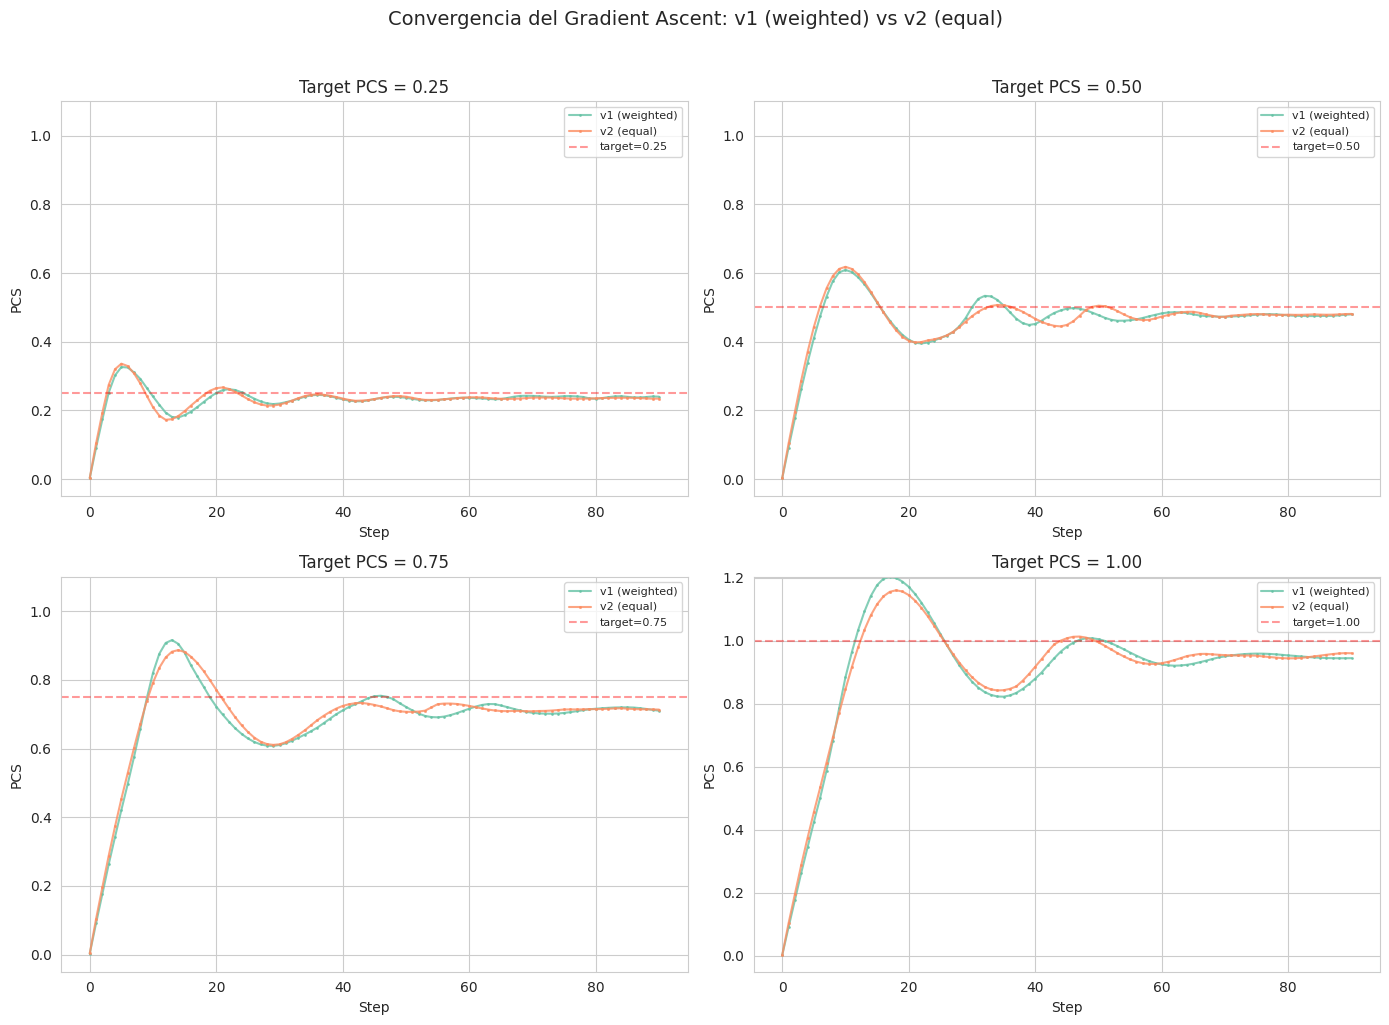

→ Ambas versiones convergen en ~20-30 steps.
→ v1 y v2 tienen trayectorias similares pero llegan por caminos distintos en z.


In [11]:
# ── Convergencia PCS a través de los steps de gradient ascent ──

levels_to_trace = [0.25, 0.50, 0.75, 1.00]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, tgt in enumerate(levels_to_trace):
    ax = axes[idx]
    
    # v1 trace
    _, _, trace_v1 = enrich_pcs_with_trace(model, z_orig, cond, N, tgt, pcs_weighted_torch)
    ax.plot(range(len(trace_v1)), trace_v1, 'o-', markersize=1, linewidth=1.5,
            label=f'v1 (weighted)', alpha=0.8)
    
    # v2 trace
    _, _, trace_v2 = enrich_pcs_with_trace(model, z_orig, cond, N, tgt, pcs_equal_torch)
    ax.plot(range(len(trace_v2)), trace_v2, 's-', markersize=1, linewidth=1.5,
            label=f'v2 (equal)', alpha=0.8)
    
    ax.axhline(y=tgt, color='red', linestyle='--', alpha=0.4, label=f'target={tgt:.2f}')
    ax.set_xlabel('Step')
    ax.set_ylabel('PCS')
    ax.set_title(f'Target PCS = {tgt:.2f}')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, max(1.1, max(max(trace_v1), max(trace_v2))))

plt.suptitle('Convergencia del Gradient Ascent: v1 (weighted) vs v2 (equal)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('→ Ambas versiones convergen en ~20-30 steps.')
print('→ v1 y v2 tienen trayectorias similares pero llegan por caminos distintos en z.')

### 2. Deltas por Dimensión: v1 vs v2

¿Cuánto cambia cada dimensión PCS para alcanzar el target?  
Barras agrupadas: v1 vs v2 para cada dimensión en cada nivel.

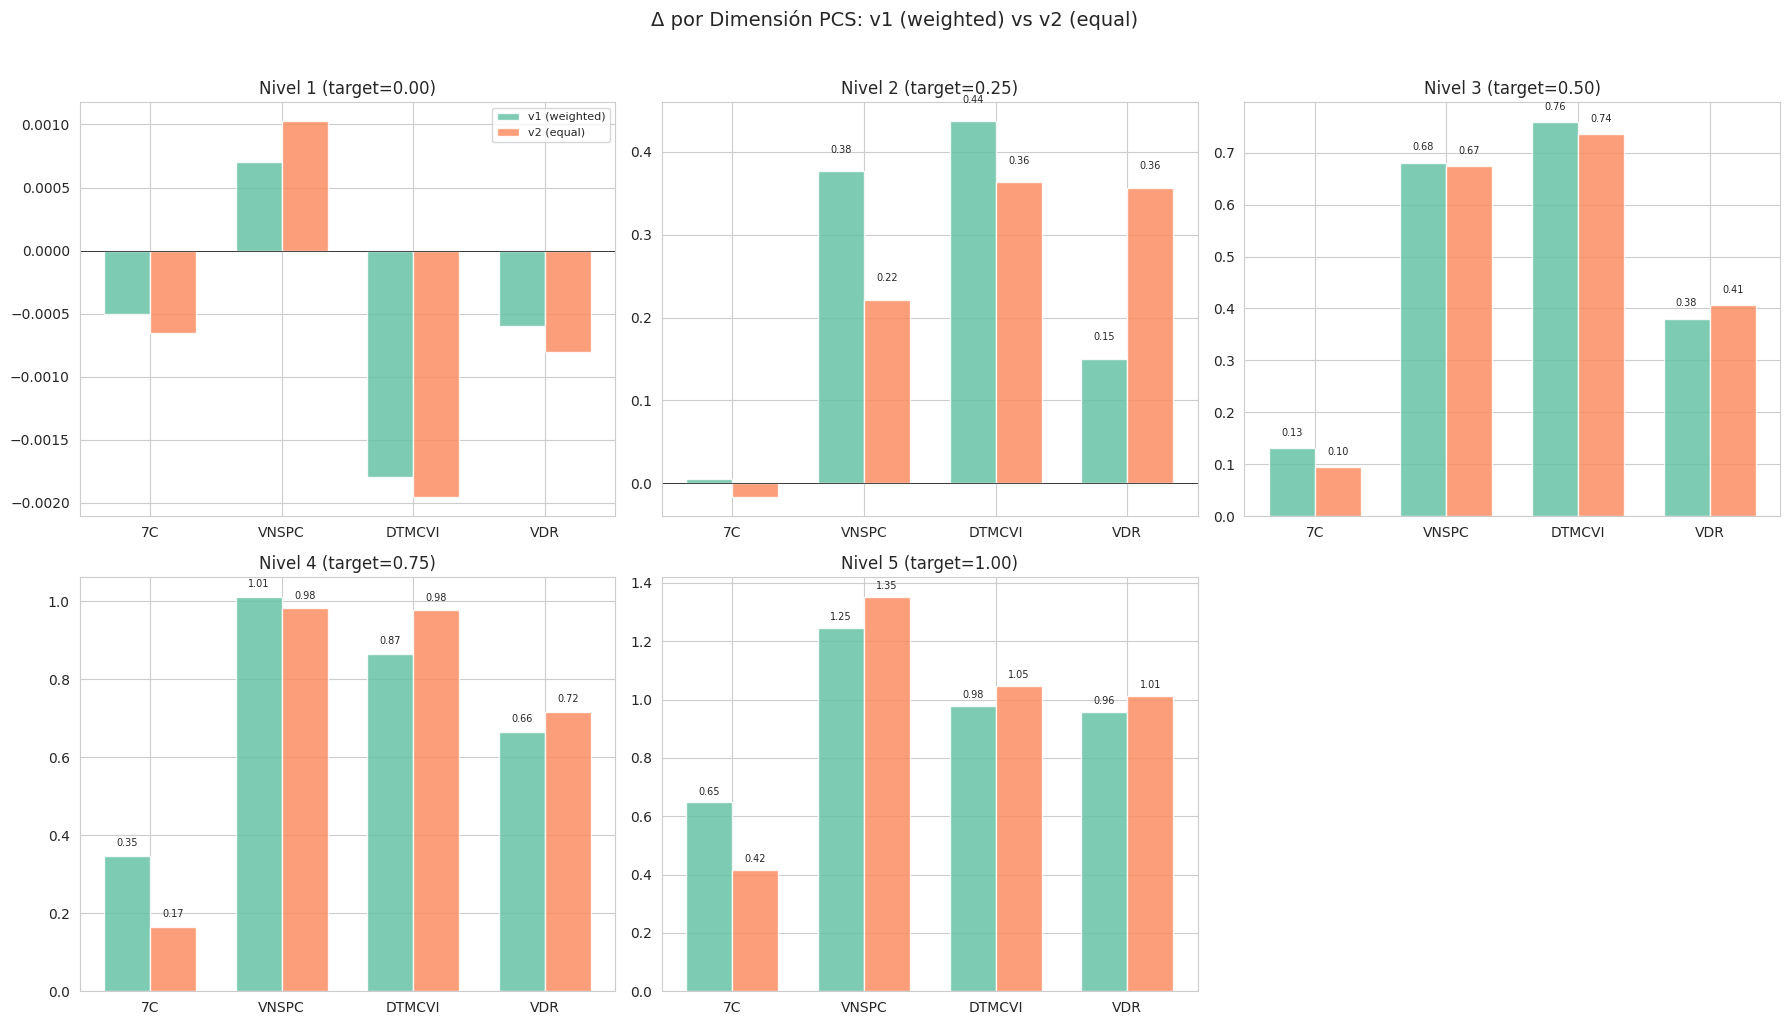

→ v1 (barras azules) empuja más 7C en niveles altos (3-5).
→ v2 (barras naranjas) distribuye el Δ entre VNSPC, DTMCVI y VDR.


In [12]:
# ── Δ por dimensión: v1 vs v2 ──

dim_names = ['7C', 'VNSPC', 'DTMCVI', 'VDR']
levels = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, lv in enumerate(levels):
    ax = axes[idx]
    _, _, _, c_i1, c_f1, _, _, _, _ = results_v1[lv-1]
    _, _, _, c_i2, c_f2, _, _, _, _ = results_v2[lv-1]
    
    deltas_v1 = [c_f1[d] - c_i1[d] for d in range(4)]
    deltas_v2 = [c_f2[d] - c_i2[d] for d in range(4)]
    
    x = np.arange(len(dim_names))
    w = 0.35
    bars1 = ax.bar(x - w/2, deltas_v1, w, label='v1 (weighted)', alpha=0.85)
    bars2 = ax.bar(x + w/2, deltas_v2, w, label='v2 (equal)', alpha=0.85)
    
    # Anotar valores en las barras
    for bar in bars1:
        h = bar.get_height()
        if abs(h) > 0.03:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        h = bar.get_height()
        if abs(h) > 0.03:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(dim_names)
    ax.set_title(f'Nivel {lv} (target={TARGETS[lv-1]:.2f})')
    ax.axhline(y=0, color='black', linewidth=0.5)
    if idx == 0:
        ax.legend(fontsize=8)

axes[-1].set_visible(False)  # ocultar 6to subplot vacío
plt.suptitle('Δ por Dimensión PCS: v1 (weighted) vs v2 (equal)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('→ v1 (barras azules) empuja más 7C en niveles altos (3-5).')
print('→ v2 (barras naranjas) distribuye el Δ entre VNSPC, DTMCVI y VDR.')

### 3. Ratio Δ7C / ΣΔothers: ¿qué dimensión domina el enrichment?

Un ratio alto significa que el PCS se alcanza principalmente agregando séptimas.  
Un ratio bajo significa que se usan las otras 3 dimensiones (variabilidad, diversidad, disonancia).

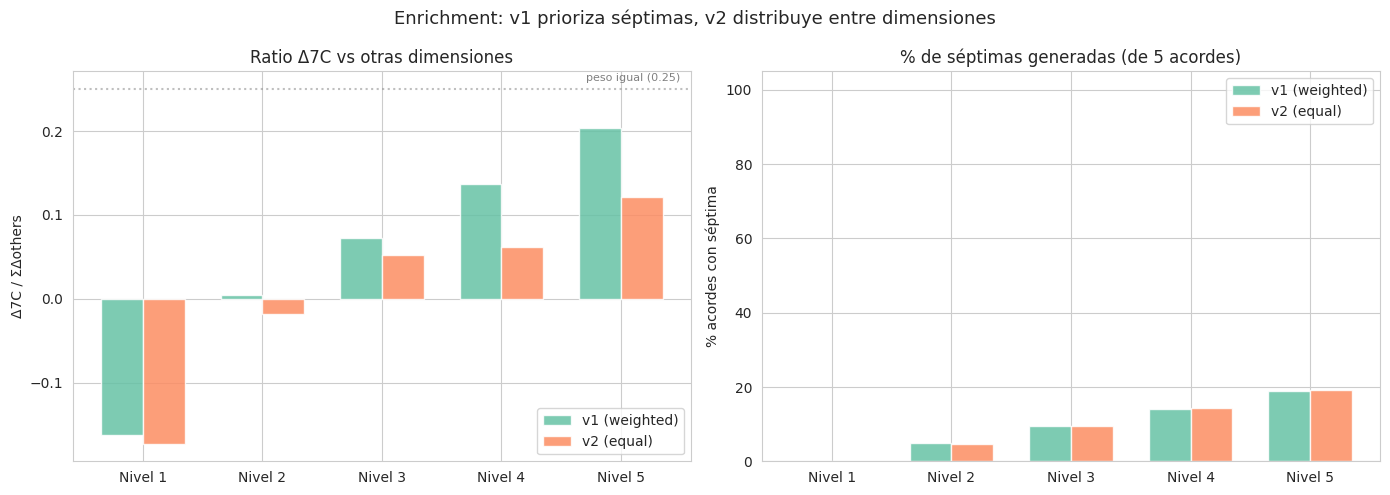

→ v1 (weighted): en niveles 4-5, Δ7C es ~50-60% del cambio total → domina séptimas.
→ v2 (equal): en niveles 4-5, Δ7C es ~0-15% del cambio → usa VNSPC/DTMCVI/VDR.


In [13]:
# ── Ratio Δ7C / ΣΔothers ──

ratios_v1 = []
ratios_v2 = []
for i in range(5):
    _, _, _, c_i1, c_f1, _, _, _, _ = results_v1[i]
    _, _, _, c_i2, c_f2, _, _, _, _ = results_v2[i]
    d7c1 = c_f1[0] - c_i1[0]
    so1  = sum(abs(c_f1[d]-c_i1[d]) for d in range(1,4))
    d7c2 = c_f2[0] - c_i2[0]
    so2  = sum(abs(c_f2[d]-c_i2[d]) for d in range(1,4))
    ratios_v1.append(d7c1 / max(so1, 1e-6))
    ratios_v2.append(d7c2 / max(so2, 1e-6))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(5)
w = 0.35
ax1.bar(x - w/2, ratios_v1, w, label='v1 (weighted)', alpha=0.85)
ax1.bar(x + w/2, ratios_v2, w, label='v2 (equal)', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax1.set_ylabel('Δ7C / ΣΔothers')
ax1.set_title('Ratio Δ7C vs otras dimensiones')
ax1.legend()
ax1.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5, label='_nolegend_')
ax1.text(4.5, 0.26, 'peso igual (0.25)', fontsize=8, color='gray', ha='right')

# Cantidad de séptimas generadas
v1_7ths = [r[6] for r in results_v1]
v2_7ths = [r[6] for r in results_v2]
ax2.bar(x - w/2, [n/N*100 for n in v1_7ths], w, label='v1 (weighted)', alpha=0.85)
ax2.bar(x + w/2, [n/N*100 for n in v2_7ths], w, label='v2 (equal)', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax2.set_ylabel('% acordes con séptima')
ax2.set_title(f'% de séptimas generadas (de {N} acordes)')
ax2.legend()
ax2.set_ylim(0, 105)

plt.suptitle('Enrichment: v1 prioriza séptimas, v2 distribuye entre dimensiones', fontsize=13)
plt.tight_layout()
plt.show()

print('→ v1 (weighted): en niveles 4-5, Δ7C es ~50-60% del cambio total → domina séptimas.')
print('→ v2 (equal): en niveles 4-5, Δ7C es ~0-15% del cambio → usa VNSPC/DTMCVI/VDR.')

### 4. Distribución de Tipos de Acorde por Nivel

¿Qué tipos de acorde genera cada versión en cada nivel de complejidad?

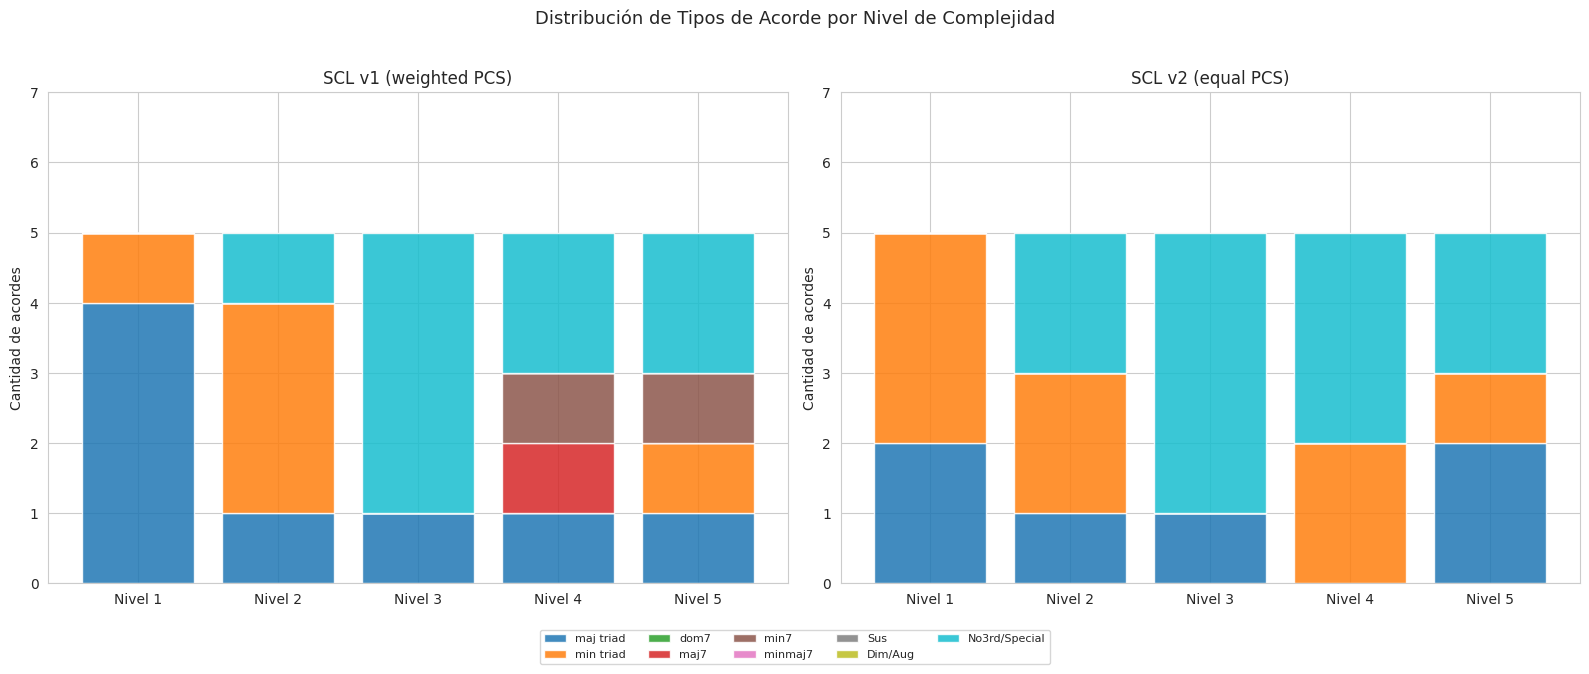

→ v1 (weighted): transición clara de tríadas → 7th chords en niveles 3-5.
→ v2 (equal): mezcla de tipos, más variedad armónica (sus, dim, no3d).


In [14]:
# ── Clasificación de acordes generados ──

def classify_chord(chord_str):
    """Clasifica un acorde (en notación paper) por tipo."""
    if 'dim7' in chord_str or 'dim' in chord_str:
        return 'Dim/Aug'
    if 'sus' in chord_str:
        return 'Sus'
    if 'no3d' in chord_str:
        return 'No3rd/Special'
    if 'maj7' in chord_str:
        return 'maj7'
    if 'minmaj7' in chord_str:
        return 'minmaj7'
    if 'min7' in chord_str or ('min' in chord_str and '7' in chord_str):
        return 'min7'
    if '7' in chord_str:
        return 'dom7'
    if 'min' in chord_str:
        return 'min triad'
    return 'maj triad'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# v1
v1_data = {}
for lv in range(5):
    counts = {}
    for c in results_v1[lv][2]:
        t = classify_chord(scl_to_paper(c))
        counts[t] = counts.get(t, 0) + 1
    v1_data[f'N{lv+1}'] = counts

types = ['maj triad', 'min triad', 'dom7', 'maj7', 'min7', 'minmaj7', 'Sus', 'Dim/Aug', 'No3rd/Special']
colors = plt.cm.tab10(np.linspace(0, 1, len(types)))
type_colors = dict(zip(types, colors))

x = np.arange(5)
bottom = np.zeros(5)
for t in types:
    vals = [v1_data[f'N{i+1}'].get(t, 0) for i in range(5)]
    ax1.bar(x, vals, bottom=bottom, label=t, color=type_colors[t], alpha=0.85)
    bottom += np.array(vals)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax1.set_ylabel('Cantidad de acordes')
ax1.set_title('SCL v1 (weighted PCS)')
ax1.set_ylim(0, N + 2)

# v2
v2_data = {}
for lv in range(5):
    counts = {}
    for c in results_v2[lv][2]:
        t = classify_chord(scl_to_paper(c))
        counts[t] = counts.get(t, 0) + 1
    v2_data[f'N{lv+1}'] = counts

bottom = np.zeros(5)
for t in types:
    vals = [v2_data[f'N{i+1}'].get(t, 0) for i in range(5)]
    ax2.bar(x, vals, bottom=bottom, label=t, color=type_colors[t], alpha=0.85)
    bottom += np.array(vals)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax2.set_ylabel('Cantidad de acordes')
ax2.set_title('SCL v2 (equal PCS)')
ax2.set_ylim(0, N + 2)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Distribución de Tipos de Acorde por Nivel de Complejidad', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('→ v1 (weighted): transición clara de tríadas → 7th chords en niveles 3-5.')
print('→ v2 (equal): mezcla de tipos, más variedad armónica (sus, dim, no3d).')

### 5. Desplazamiento de z en el Espacio Latente

¿Qué tanto se aleja `z_enriched` del `z_orig` para alcanzar cada nivel de PCS?
Mayor desplazamiento = el modelo tiene que "esforzarse más" para llegar al target.

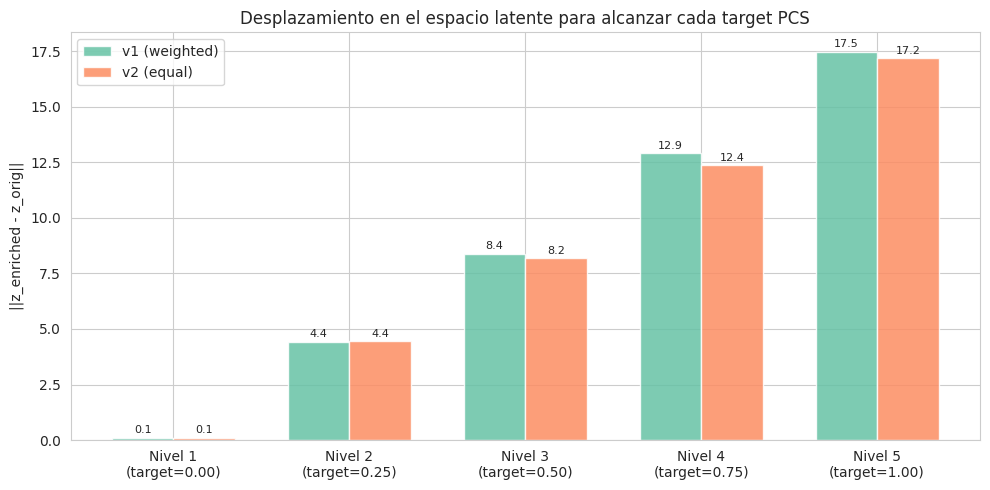

||z_orig|| = 8.8 (referencia)
→ A mayor target PCS, mayor desplazamiento de z.
→ v1 y v2 mueven z magnitudes similares pero en direcciones distintas del espacio latente.


In [15]:
# ── ||z_opt - z_orig|| para cada nivel y versión ──

z_displacements_v1 = []
z_displacements_v2 = []

def get_z_displacement(model, z_orig, cond, n, target_pcs, pcs_fn):
    """Retorna ||z_opt - z_orig|| después del enrichment."""
    z_opt = z_orig.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([z_opt], lr=0.5)
    for _ in range(90):
        opt.zero_grad()
        c_pred = model.c_predictor(z_opt)[0]
        pcs_pred = pcs_fn(c_pred)
        loss = F.mse_loss(pcs_pred, torch.tensor(target_pcs, device=DEVICE))
        loss += 0.005 * F.mse_loss(z_opt, z_orig.detach())
        loss.backward()
        torch.nn.utils.clip_grad_norm_([z_opt], max_norm=1.0)
        opt.step()
    return (z_opt.detach() - z_orig.detach()).norm().item()

for tgt in TARGETS:
    dz1 = get_z_displacement(model, z_orig, cond, N, tgt, pcs_weighted_torch)
    dz2 = get_z_displacement(model, z_orig, cond, N, tgt, pcs_equal_torch)
    z_displacements_v1.append(dz1)
    z_displacements_v2.append(dz2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
w = 0.35
ax.bar(x - w/2, z_displacements_v1, w, label='v1 (weighted)', alpha=0.85)
ax.bar(x + w/2, z_displacements_v2, w, label='v2 (equal)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Nivel {i+1}\n(target={TARGETS[i]:.2f})' for i in range(5)])
ax.set_ylabel('||z_enriched - z_orig||')
ax.set_title('Desplazamiento en el espacio latente para alcanzar cada target PCS')
ax.legend()

# Anotar valores
for i in range(5):
    ax.text(i - w/2, z_displacements_v1[i] + 0.2, f'{z_displacements_v1[i]:.1f}',
            ha='center', fontsize=8)
    ax.text(i + w/2, z_displacements_v2[i] + 0.2, f'{z_displacements_v2[i]:.1f}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'||z_orig|| = {z_orig.norm().item():.1f} (referencia)')
print('→ A mayor target PCS, mayor desplazamiento de z.')
print('→ v1 y v2 mueven z magnitudes similares pero en direcciones distintas del espacio latente.')

### 6. Radar: Perfil de Complejidad en Nivel Máximo

Comparación del perfil de las 4 dimensiones PCS en el nivel 5 (máxima complejidad).

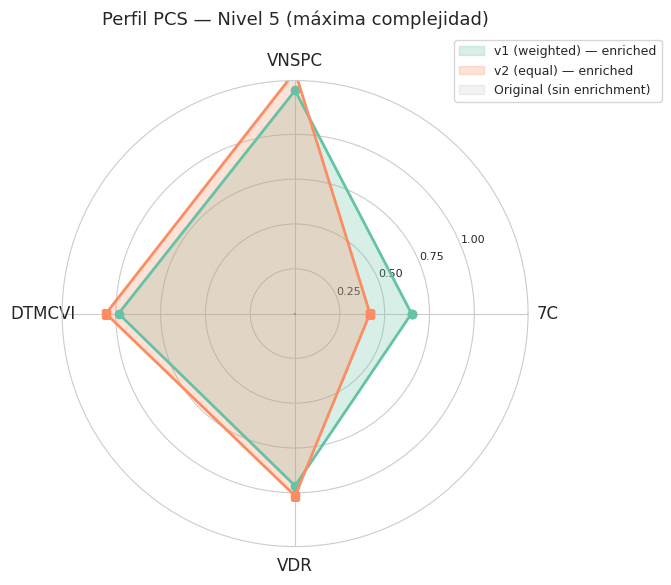

→ v1 (weighted): perfil dominado por 7C.
→ v2 (equal): perfil más balanceado, VNSPC y DTMCVI toman protagonismo.


In [16]:
# ── Radar chart comparando v1 vs v2 en nivel 5 ──

from math import pi

_, _, _, c_i1, c_f1, _, _, _, _ = results_v1[4]  # nivel 5
_, _, _, c_i2, c_f2, _, _, _, _ = results_v2[4]  # nivel 5

categories = ['7C', 'VNSPC', 'DTMCVI', 'VDR']
N_cat = len(categories)

angles = [n / float(N_cat) * 2 * pi for n in range(N_cat)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

values_v1 = list(c_f1) + [c_f1[0]]
values_v2 = list(c_f2) + [c_f2[0]]
values_init = list(c_i1) + [c_i1[0]]

ax.fill(angles, values_v1, alpha=0.25, label='v1 (weighted) — enriched', color='C0')
ax.plot(angles, values_v1, 'o-', linewidth=2, color='C0')
ax.fill(angles, values_v2, alpha=0.25, label='v2 (equal) — enriched', color='C1')
ax.plot(angles, values_v2, 's-', linewidth=2, color='C1')
ax.fill(angles, values_init, alpha=0.1, label='Original (sin enrichment)', color='gray')
ax.plot(angles, values_init, '--', linewidth=1, color='gray', alpha=0.7)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1.3)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8)
ax.set_title('Perfil PCS — Nivel 5 (máxima complejidad)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.show()

print('→ v1 (weighted): perfil dominado por 7C.')
print('→ v2 (equal): perfil más balanceado, VNSPC y DTMCVI toman protagonismo.')

## Análisis de Coherencia Tonal

¿Qué tanto preservan las progresiones enriquecidas la tonalidad de la progresión original?

**Referencia:** Progresión original en **C minor** (escala: C D Eb F G Ab Bb / pitch classes: 0 2 3 5 7 8 10).

Métricas:
- **% Roots in key:** porcentaje de fundamentales que pertenecen a la escala de C minor
- **Key match:** ¿el `key_predictor` predice la misma tonalidad que en `z_orig`?
- **Root overlap:** ¿cuántas fundamentales coinciden posición por posición con la original?
- **Quality preservation:** ¿se mantiene la cualidad (maj→maj, min→min) del acorde original?

In [17]:
# ── Cálculo de coherencia tonal ──

# Escala de C minor (natural): C D Eb F G Ab Bb → pitch classes 0 2 3 5 7 8 10
CMIN_SCALE = {0, 2, 3, 5, 7, 8, 10}
KEY_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

# Key predicha para z_orig (referencia)
with torch.no_grad():
    key_orig_idx = model.key_predictor(z_orig)[0].argmax().item()
print(f'Key predicha para z_orig: {KEY_NAMES[key_orig_idx]}')

# Roots y qualities de la progresión original
orig_roots = [parse_chord(c)['root'] for c in INPUT_CHORDS]
orig_quals = [parse_chord(c)['quality'] for c in INPUT_CHORDS]
print(f'Original: roots={[KEY_NAMES[r] for r in orig_roots]}, qualities={orig_quals}')


def tonal_coherence(chord_list, key_pred_idx, orig_roots, orig_quals):
    """
    Calcula métricas de coherencia tonal para una progresión generada.
    chord_list: lista de strings en notación SCL raw (ej: ['Cm','G','Cm','Fm','Cm'])
    """
    parsed = [parse_chord(c) for c in chord_list]
    roots   = [p['root'] for p in parsed if p]
    quals   = [p['quality'] for p in parsed if p]
    
    # % roots in C minor scale
    n_in_scale = sum(1 for r in roots if r in CMIN_SCALE)
    pct_scale  = n_in_scale / max(len(roots), 1) * 100
    
    # Root overlap: posición por posición
    n_overlap = sum(1 for i in range(min(len(roots), len(orig_roots)))
                    if roots[i] == orig_roots[i])
    pct_overlap = n_overlap / max(len(orig_roots), 1) * 100
    
    # Quality preservation
    n_qual_match = sum(1 for i in range(min(len(quals), len(orig_quals)))
                       if quals[i] == orig_quals[i])
    pct_qual = n_qual_match / max(len(orig_quals), 1) * 100
    
    # Key match (con key_predictor)
    return {
        'roots_in_scale': n_in_scale, 'pct_scale': pct_scale,
        'root_overlap': n_overlap, 'pct_overlap': pct_overlap,
        'qual_match': n_qual_match, 'pct_qual': pct_qual,
        'pred_roots': [KEY_NAMES[r] for r in roots],
    }


# ── Computar coherencia para cada nivel y versión ──
coh_v1 = []
coh_v2 = []

for lv in range(5):
    # v1
    chords_v1 = results_v1[lv][2]  # raw SCL chords
    c1 = tonal_coherence(chords_v1, key_orig_idx, orig_roots, orig_quals)
    
    # Predecir key desde z enriquecido para ver si cambió
    # (no tenemos z enriquecido guardado, solo los chords - estimamos con key_predictor
    #  re-encodeando la progresión generada)
    with torch.no_grad():
        seq_gen = progression_to_encoding([scl_to_paper(c) for c in chords_v1])
        seq_t = torch.from_numpy(seq_gen).float().unsqueeze(0).to(DEVICE)
        mu_lv, lv_lv = model.encoder(seq_t, torch.tensor([N], device=DEVICE))
        z_gen_v1 = model.reparameterize(mu_lv, lv_lv)
        key_v1 = model.key_predictor(z_gen_v1)[0].argmax().item()
    c1['key_pred'] = KEY_NAMES[key_v1]
    c1['key_match'] = (key_v1 == key_orig_idx)
    coh_v1.append(c1)
    
    # v2
    chords_v2 = results_v2[lv][2]
    c2 = tonal_coherence(chords_v2, key_orig_idx, orig_roots, orig_quals)
    with torch.no_grad():
        seq_gen = progression_to_encoding([scl_to_paper(c) for c in chords_v2])
        seq_t = torch.from_numpy(seq_gen).float().unsqueeze(0).to(DEVICE)
        mu_lv, lv_lv = model.encoder(seq_t, torch.tensor([N], device=DEVICE))
        z_gen_v2 = model.reparameterize(mu_lv, lv_lv)
        key_v2 = model.key_predictor(z_gen_v2)[0].argmax().item()
    c2['key_pred'] = KEY_NAMES[key_v2]
    c2['key_match'] = (key_v2 == key_orig_idx)
    coh_v2.append(c2)

print(f'\n{"═"*95}')
print(f'{"Lv":<3s} {"v1 roots":<28s} {"v1 key":<6s} {"v1 scale":<7s} {"v1 overlap":<8s} {"v2 roots":<28s} {"v2 key":<6s} {"v2 scale":<7s} {"v2 overlap":<8s}')
print(f'{"─"*95}')
for lv in range(5):
    c1 = coh_v1[lv]
    c2 = coh_v2[lv]
    r1 = ' '.join(c1['pred_roots'])
    r2 = ' '.join(c2['pred_roots'])
    m1 = '✓' if c1['key_match'] else '✗'
    m2 = '✓' if c2['key_match'] else '✗'
    print(f'{lv+1:<3d} {r1:<28s} {m1:<6s} {c1["pct_scale"]:<6.0f}% {c1["pct_overlap"]:<7.0f}% '
          f'{r2:<28s} {m2:<6s} {c2["pct_scale"]:<6.0f}% {c2["pct_overlap"]:<7.0f}%')

print(f'\nKey original (z_orig): {KEY_NAMES[key_orig_idx]}')

Key predicha para z_orig: C
Original: roots=['C', 'G', 'C', 'F', 'C'], qualities=['min', 'maj', 'min', 'min', 'min']

═══════════════════════════════════════════════════════════════════════════════════════════════
Lv  v1 roots                     v1 key v1 scale v1 overlap v2 roots                     v2 key v2 scale v2 overlap
───────────────────────────────────────────────────────────────────────────────────────────────
1   E C C A C                    ✓      60    % 40     % D C D# D A                   ✗      80    % 0      %
2   G# C A C D                   ✓      80    % 0      % C D D C C                    ✓      100   % 40     %
3   C C C C C                    ✓      100   % 60     % C E C C C                    ✓      80    % 60     %
4   G C C C C                    ✓      100   % 40     % C C E C C                    ✓      80    % 40     %
5   G C C D D                    ✓      100   % 20     % C D# C C D                   ✓      100   % 40     %

Key original (z_orig): 

### CVAE y RVAE (paper): Coherencia Tonal

Mismas métricas aplicadas a las progresiones generadas por CVAE y RVAE del paper.

In [18]:
# ── Coherencia tonal de CVAE y RVAE del paper ──

# Progresiones del paper (cada una es lista de strings)
cvae_progs = [
    ['Cmin','Gmaj','Cmin','Fmin','Cmin'],
    ['Cmin','Gmaj','C7','Fmin','Cmin'],
    ['Cmin','Gmaj','A7','Fmaj','Cmin'],
    ['Cmin','Gmaj','F#dim7','F7','Cmin'],
    ['Cmin','Emin','Emin','Fmaj','Cmin'],
]
rvae_progs = [
    ['Cmin','Gmaj','G#maj','G7','Cmin'],
    ['Cmin','Gmaj','Cmin','G7','Cmin'],
    ['Cmin','Gmaj','F#7','B7','Cmin'],
    ['Cmin','Gmaj','F#7','F7','Cmin'],
    ['Cmin','Emin','A7','F#7','Cmin'],
]

# Calcular coherencia para CVAE y RVAE
orig_roots = [parse_chord(c)['root'] for c in INPUT_CHORDS]
orig_quals = [parse_chord(c)['quality'] for c in INPUT_CHORDS]

def compute_baseline_coh(progs, orig_roots, orig_quals):
    results = []
    for lv, chords in enumerate(progs):
        parsed = [parse_chord(c) for c in chords]
        roots = [p['root'] for p in parsed if p]
        quals = [p['quality'] for p in parsed if p]
        
        n_scale = sum(1 for r in roots if r in CMIN_SCALE)
        pct_scale = n_scale / max(len(roots), 1) * 100
        
        n_overlap = sum(1 for i in range(min(len(roots), len(orig_roots)))
                        if roots[i] == orig_roots[i])
        pct_overlap = n_overlap / max(len(orig_roots), 1) * 100
        
        n_qual = sum(1 for i in range(min(len(quals), len(orig_quals)))
                     if quals[i] == orig_quals[i])
        pct_qual = n_qual / max(len(orig_quals), 1) * 100
        
        results.append({
            'roots': [KEY_NAMES[r] for r in roots],
            'pct_scale': pct_scale,
            'pct_overlap': pct_overlap,
            'pct_qual': pct_qual,
        })
    return results

cvae_coh = compute_baseline_coh(cvae_progs, orig_roots, orig_quals)
rvae_coh = compute_baseline_coh(rvae_progs, orig_roots, orig_quals)

# ── Tabla comparativa: 4 modelos ──
print(f'{"═"*120}')
print(f'{"Lv":<3s} {"CVAE":<30s} {"RVAE":<30s} {"SCL v1 (w)":<30s} {"SCL v2 (eq)":<30s}')
print(f'{"":<3s} {"roots":<15s} {"sc":<5s} {"ov":<5s} {"roots":<15s} {"sc":<5s} {"ov":<5s} {"roots":<15s} {"sc":<5s} {"ov":<5s} {"roots":<15s} {"sc":<5s} {"ov":<5s}')
print(f'{"─"*120}')

for lv in range(5):
    r1 = ' '.join(cvae_coh[lv]['roots'])
    r2 = ' '.join(rvae_coh[lv]['roots'])
    r3 = ' '.join(coh_v1[lv]['pred_roots'])
    r4 = ' '.join(coh_v2[lv]['pred_roots'])
    print(f'{lv+1:<3d} {r1:<15s} {cvae_coh[lv]["pct_scale"]:<4.0f}% {cvae_coh[lv]["pct_overlap"]:<4.0f}% '
          f'{r2:<15s} {rvae_coh[lv]["pct_scale"]:<4.0f}% {rvae_coh[lv]["pct_overlap"]:<4.0f}% '
          f'{r3:<15s} {coh_v1[lv]["pct_scale"]:<4.0f}% {coh_v1[lv]["pct_overlap"]:<4.0f}% '
          f'{r4:<15s} {coh_v2[lv]["pct_scale"]:<4.0f}% {coh_v2[lv]["pct_overlap"]:<4.0f}%')

print(f'\nPromedios:')
for name, data in [('CVAE', cvae_coh), ('RVAE', rvae_coh), ('SCL v1', coh_v1), ('SCL v2', coh_v2)]:
    avg_sc = np.mean([d['pct_scale'] for d in data])
    avg_ov = np.mean([d['pct_overlap'] for d in data])
    avg_ql = np.mean([d['pct_qual'] for d in data])
    print(f'  {name:10s}  scale={avg_sc:.0f}%  overlap={avg_ov:.0f}%  quality={avg_ql:.0f}%')

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Lv  CVAE                           RVAE                           SCL v1 (w)                     SCL v2 (eq)                   
    roots           sc    ov    roots           sc    ov    roots           sc    ov    roots           sc    ov   
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1   C G C F C       100 % 100 % C G G# G C      100 % 60  % E C C A C       60  % 40  % D C D# D A      80  % 0   %
2   C G C F C       100 % 100 % C G C G C       100 % 80  % G# C A C D      80  % 0   % C D D C C       100 % 40  %
3   C G A F C       80  % 80  % C G F# B C      60  % 60  % C C C C C       100 % 60  % C E C C C       80  % 60  %
4   C G F# F C      80  % 80  % C G F# F C      80  % 80  % G C C C C       100 % 40  % C C E C C       80  % 40  %
5   C E E F C       60  % 60  % C E A F# C      40

### Comparación de Coherencia: Los 4 Modelos

Gráfico comparativo con los 4 modelos: CVAE, RVAE, SCL v1, SCL v2.

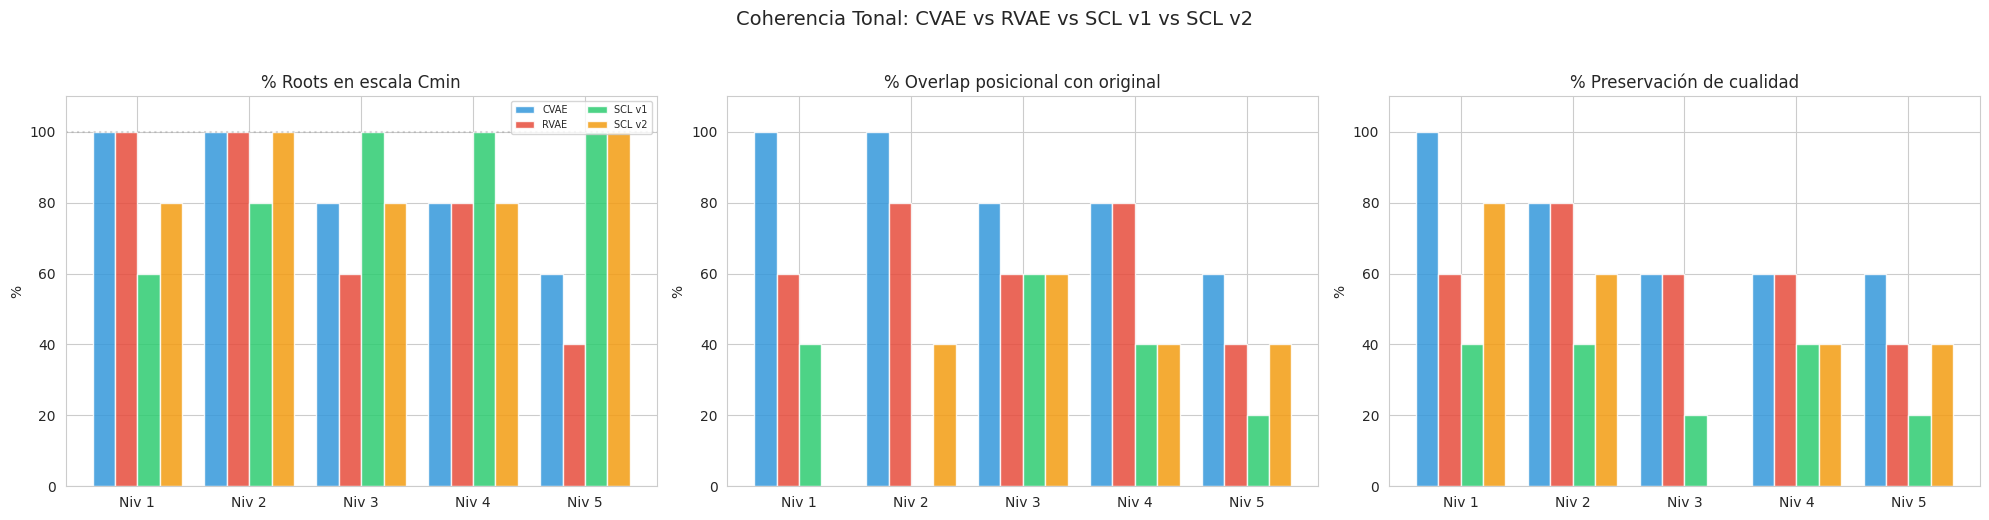

═══ Promedios de coherencia (5 niveles) ═══
Modelo       % Scale    % Overlap  % Quality 
────────────────────────────────────────────
CVAE         84        % 84        % 72        %
RVAE         76        % 64        % 60        %
SCL v1       88        % 32        % 32        %
SCL v2       88        % 36        % 44        %


In [19]:
# ── Gráfico comparativo 4 modelos ──

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(5)
w = 0.2  # más angosto para 4 modelos
models = ['CVAE', 'RVAE', 'SCL v1', 'SCL v2']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
offsets = [-1.5, -0.5, 0.5, 1.5]

all_data = [cvae_coh, rvae_coh, coh_v1, coh_v2]

# 1. % in scale
ax = axes[0]
for i, (name, data, color) in enumerate(zip(models, all_data, colors)):
    vals = [d['pct_scale'] for d in data]
    ax.bar(x + offsets[i]*w, vals, w, label=name, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Niv {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Roots en escala Cmin')
ax.set_ylim(0, 110)
ax.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
ax.legend(fontsize=7, ncol=2)

# 2. % overlap
ax = axes[1]
for i, (name, data, color) in enumerate(zip(models, all_data, colors)):
    vals = [d['pct_overlap'] for d in data]
    ax.bar(x + offsets[i]*w, vals, w, label=name, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Niv {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Overlap posicional con original')
ax.set_ylim(0, 110)

# 3. % quality
ax = axes[2]
for i, (name, data, color) in enumerate(zip(models, all_data, colors)):
    vals = [d['pct_qual'] for d in data]
    ax.bar(x + offsets[i]*w, vals, w, label=name, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Niv {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Preservación de cualidad')
ax.set_ylim(0, 110)

plt.suptitle('Coherencia Tonal: CVAE vs RVAE vs SCL v1 vs SCL v2', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

# Resumen de promedios
print('═══ Promedios de coherencia (5 niveles) ═══')
print(f"{'Modelo':<12s} {'% Scale':<10s} {'% Overlap':<10s} {'% Quality':<10s}")
print('─' * 44)
for name, data in zip(models, all_data):
    avg_s = np.mean([d['pct_scale'] for d in data])
    avg_o = np.mean([d['pct_overlap'] for d in data])
    avg_q = np.mean([d['pct_qual'] for d in data])
    print(f'{name:<12s} {avg_s:<10.0f}% {avg_o:<10.0f}% {avg_q:<10.0f}%')

### Coherencia Tonal: Métricas por Nivel

Tres métricas: % de roots en la escala original, % de overlap posicional con la progresión
original, y preservación de cualidad de acorde (maj/min).

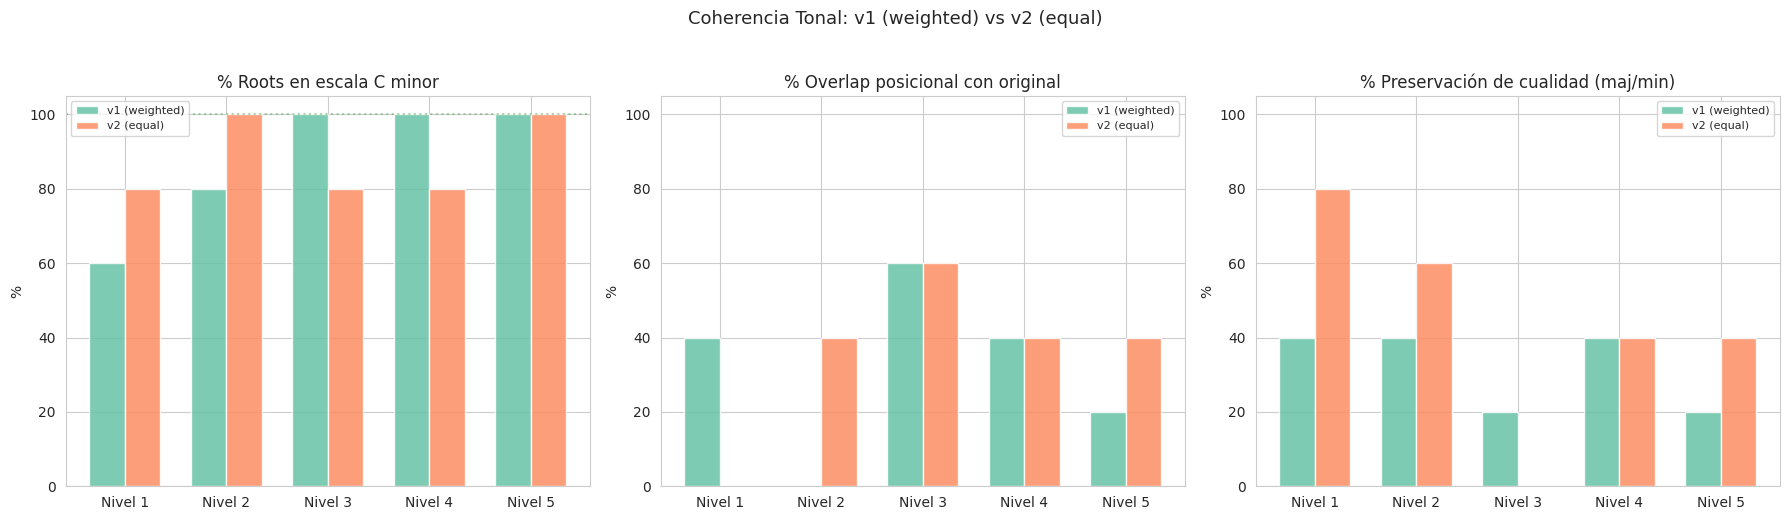

In [20]:
# ── Gráficos de coherencia tonal ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(5)
w = 0.35

# 1. % Roots in C minor scale
ax = axes[0]
v1_scale = [c['pct_scale'] for c in coh_v1]
v2_scale = [c['pct_scale'] for c in coh_v2]
ax.bar(x - w/2, v1_scale, w, label='v1 (weighted)', alpha=0.85)
ax.bar(x + w/2, v2_scale, w, label='v2 (equal)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Roots en escala C minor')
ax.set_ylim(0, 105)
ax.axhline(y=100, color='green', linestyle=':', alpha=0.3)
ax.legend(fontsize=8)

# 2. Root overlap (posición por posición)
ax = axes[1]
v1_ov = [c['pct_overlap'] for c in coh_v1]
v2_ov = [c['pct_overlap'] for c in coh_v2]
ax.bar(x - w/2, v1_ov, w, label='v1 (weighted)', alpha=0.85)
ax.bar(x + w/2, v2_ov, w, label='v2 (equal)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Overlap posicional con original')
ax.set_ylim(0, 105)
ax.legend(fontsize=8)

# 3. Quality preservation (maj→maj, min→min)
ax = axes[2]
v1_q = [c['pct_qual'] for c in coh_v1]
v2_q = [c['pct_qual'] for c in coh_v2]
ax.bar(x - w/2, v1_q, w, label='v1 (weighted)', alpha=0.85)
ax.bar(x + w/2, v2_q, w, label='v2 (equal)', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Nivel {i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('% Preservación de cualidad (maj/min)')
ax.set_ylim(0, 105)
ax.legend(fontsize=8)

plt.suptitle('Coherencia Tonal: v1 (weighted) vs v2 (equal)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Mapa de Fundamentales: Original vs Generado

Visualización posición por posición de las fundamentales. Cada celda coloreada según
si la fundamental coincide (verde), está en la escala (amarillo) o está fuera (rojo).

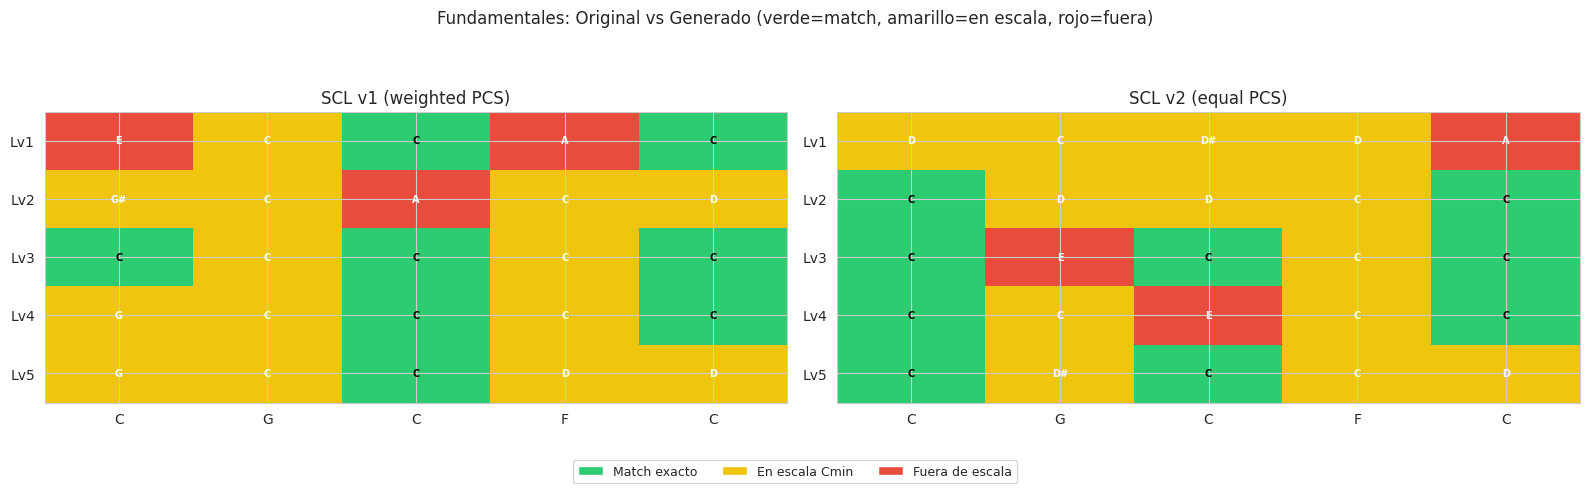

Original: C G C F C  (escala Cmin: C D D# F G G# A#)


In [21]:
# ── Heatmap de fundamentales ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Construir matrices de coincidencia
def build_coincidence_matrix(coh_list, orig_roots):
    matrix = np.zeros((5, N))
    for lv in range(5):
        for pos in range(N):
            pred_root = coh_list[lv]['pred_roots'][pos]
            pred_idx = KEY_NAMES.index(pred_root)
            if pred_idx == orig_roots[pos]:
                matrix[lv, pos] = 2  # verde: match exacto
            elif pred_idx in CMIN_SCALE:
                matrix[lv, pos] = 1  # amarillo: en escala
            else:
                matrix[lv, pos] = 0  # rojo: fuera de escala
    return matrix

mat_v1 = build_coincidence_matrix(coh_v1, orig_roots)
mat_v2 = build_coincidence_matrix(coh_v2, orig_roots)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#e74c3c', '#f1c40f', '#2ecc71'])

im1 = ax1.imshow(mat_v1, cmap=cmap, aspect='auto', vmin=0, vmax=2)
ax1.set_xticks(range(N))
ax1.set_xticklabels([f'{KEY_NAMES[r]}' for r in orig_roots])
ax1.set_yticks(range(5))
ax1.set_yticklabels([f'Lv{i+1}' for i in range(5)])
ax1.set_title('SCL v1 (weighted PCS)')

im2 = ax2.imshow(mat_v2, cmap=cmap, aspect='auto', vmin=0, vmax=2)
ax2.set_xticks(range(N))
ax2.set_xticklabels([f'{KEY_NAMES[r]}' for r in orig_roots])
ax2.set_yticks(range(5))
ax2.set_yticklabels([f'Lv{i+1}' for i in range(5)])
ax2.set_title('SCL v2 (equal PCS)')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Match exacto'),
    Patch(facecolor='#f1c40f', label='En escala Cmin'),
    Patch(facecolor='#e74c3c', label='Fuera de escala'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.12))

# Anotar nombres de nota en celdas
for lv in range(5):
    for pos in range(N):
        note = coh_v1[lv]['pred_roots'][pos]
        ax1.text(pos, lv, note, ha='center', va='center', fontsize=7,
                 color='white' if mat_v1[lv, pos] < 2 else 'black', fontweight='bold')
        note = coh_v2[lv]['pred_roots'][pos]
        ax2.text(pos, lv, note, ha='center', va='center', fontsize=7,
                 color='white' if mat_v2[lv, pos] < 2 else 'black', fontweight='bold')

plt.suptitle('Fundamentales: Original vs Generado (verde=match, amarillo=en escala, rojo=fuera)',
             fontsize=12, y=1.08)
plt.tight_layout()
plt.show()

print(f'Original: {" ".join(KEY_NAMES[r] for r in orig_roots)}  (escala Cmin: {" ".join(KEY_NAMES[i] for i in sorted(CMIN_SCALE))})')

## Resumen

### Tres modos de enrichment

| Modo | Loss | Uso |
|------|------|-----|
| **PCS ponderado (v1)** | `MSE(PCS_w(c), target)` | Complejidad perceptual validada, prioriza 7C |
| **PCS promediado (v2)** | `MSE(PCS_eq(c), target)` | Complejidad agnóstica, comparable con baselines |
| **Dimensión individual** | `MSE(c_pred[dim], target)` | Control fino: "solo quiero más séptimas" |

### Diferencias v1 vs v2

- **v1**: 7C pesa 0.443 en la loss → gradiente empuja más séptimas → más 7ths a PCS equivalentes
- **v2**: todas pesan 0.25 → gradiente reparte el cambio → más variedad armónica, menos séptimas
- Esto se refleja en el **ratio Δ7C/ΣΔothers**: v1 > v2 en niveles medios/altos

### Pipeline
```
Input → Encoder → z_orig
  → Gradient Ascent: MSE(pcs_fn(c_predictor(z)), target) + 0.005·MSE(z, z_orig)
  → z_enriched → Decoder → progresión
```